In [1]:
import os
PROJECT = "/Volumes/Extreme SSD/hindi-translator"
os.environ.update({
    "HF_HOME": f"{PROJECT}/cache/hf_hub",
    "HF_DATASETS_CACHE": f"{PROJECT}/cache/datasets",
    "HF_HUB_CACHE": f"{PROJECT}/cache/hf_hub",
    "TRANSFORMERS_CACHE": f"{PROJECT}/cache/transformers",
    "TMPDIR": f"{PROJECT}/tmp",
})

# Text Translation Dataset — HindEnCorp

This dataset contains Hindi–English code-mixed text (sentences where Hindi words are often written in the Roman script and mixed with English).

Source: Primarily collected from social media platforms (like Twitter, Facebook, etc.), where bilingual users mix Hindi and English in the same sentence.

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

In [3]:
df_nmt = pd.read_csv("/Volumes/Extreme SSD/Hindi_translator/Datasets/Hindi_English_Truncated_Corpus.csv")

In [4]:
df_nmt.head()

,source,english_sentence,hindi_sentence
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,ted,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,indic2012,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


In [5]:
df_nmt['source'].value_counts()

source
tides        50000
ted          39881
indic2012    37726
Name: count, dtype: int64

In [6]:
df_nmt.drop_duplicates(inplace=True)

In [7]:
df_nmt.isnull().sum()

source              0
english_sentence    2
hindi_sentence      0
dtype: int64

In [8]:
df_nmt = df_nmt.dropna(subset=['english_sentence'])

In [9]:
df_nmt.isnull().sum()

source              0
english_sentence    0
hindi_sentence      0
dtype: int64

This dataset has no missing values, so no extra steps required

In [10]:
# Noise detection functions
def check_missing_or_empty(row):
    return pd.isnull(row['english_sentence']) or pd.isnull(row['hindi_sentence']) or row['english_sentence'].strip() == "" or row['hindi_sentence'].strip() == ""

def check_length_mismatch(row, threshold=3):
    len_en = len(row['english_sentence'].split())
    len_hi = len(row['hindi_sentence'].split())
    if len_en == 0 or len_hi == 0:
        return True
    ratio = max(len_en, len_hi) / min(len_en, len_hi)
    return ratio > threshold  # Ratio too high means mismatch

def check_too_short(row, min_words=2):
    return len(row['english_sentence'].split()) < min_words or len(row['hindi_sentence'].split()) < min_words

noise_flags = df_nmt.apply(lambda row: check_missing_or_empty(row) or check_length_mismatch(row) or check_too_short(row), axis=1)
print(f"Total noisy/mismatched sentence pairs: {noise_flags.sum()} out of {len(df_nmt)}")

# Optionally view some noisy examples
print(df_nmt[noise_flags].head(5))

Total noisy/mismatched sentence pairs: 2602 out of 124827
        source          english_sentence     hindi_sentence
11   indic2012  Category: Religious Text  श्रेणी:धर्मग्रन्थ
33   indic2012                     Maine                मेन
124  indic2012             .Masterbation              मैथुन
143  indic2012               class: Agra        श्रेणी:आगरा
166  indic2012               granth list         ग्रन्थसूची


In [11]:
#Remving the noisy data from the dataset
df_nmt = df_nmt[~noise_flags].reset_index(drop=True)

In [12]:
df_nmt=df_nmt.sample(n=25000, random_state=101)
df_nmt.shape

(25000, 3)

In [13]:
# Lowercase all characters
df_nmt['english_sentence']=df_nmt['english_sentence'].apply(lambda x: x.lower())
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: x.lower())

In [14]:
# Remove quotes
import re
df_nmt['english_sentence']=df_nmt['english_sentence'].apply(lambda x: re.sub("'", '', x))
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: re.sub("'", '', x))

In [15]:
import string
exclude = set(string.punctuation) # Set of all special characters
# Remove all the special characters
df_nmt['english_sentence']=df_nmt['english_sentence'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))

In [16]:
# Remove extra spaces
df_nmt['english_sentence']=df_nmt['english_sentence'].apply(lambda x: x.strip())
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: x.strip())
df_nmt['english_sentence']=df_nmt['english_sentence'].apply(lambda x: re.sub(" +", " ", x))
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: re.sub(" +", " ", x))

In [17]:
#removing any stray english or hindi alphabets in the opposite column
df_nmt['hindi_sentence']=df_nmt['hindi_sentence'].apply(lambda x: re.sub("[a-zA-Z]", " ", x))

In [18]:
import unicodedata
# Example DataFrame with Hindi and English sentences

def normalize_text(text):
    if isinstance(text, str):
        return unicodedata.normalize('NFC', text)
    else:
        return text  # Return as is if not string or NaN

# Apply normalization to both language columns
df_nmt['hindi_sentence'] = df_nmt['hindi_sentence'].apply(normalize_text)
df_nmt['english_sentence'] = df_nmt['english_sentence'].apply(normalize_text)

# Verify
print(df_nmt[['hindi_sentence', 'english_sentence']].head())

                                          hindi_sentence  \
21946             वे 16 साल की उम्र तक स्कूल में पढ़ेंगी   
44635  प्रत्येक रिलीज से पहले वह नकारात्मक रवैये में ...   
44970  वैसे तो यह पहले दौर के समान ही है किंतु अंतर य...   
18658             जो की जलवायु के संकट का समाधान कर सके।   
30405  इसी से जुड़ा दूसरा पहलू है खांडसारी उद्योग को ...   

                                        english_sentence  
21946              theyll stay in school until theyre 16  
44635  each release before he was responding to the n...  
44970  it is similar to the earlier type but has a bu...  
18658                 that will solve the climate crisis  
30405  another related aspect is the regulation of th...  


In [19]:
df_nmt.head()

,source,english_sentence,hindi_sentence
21946,ted,theyll stay in school until theyre 16,वे 16 साल की उम्र तक स्कूल में पढ़ेंगी
44635,indic2012,each release before he was responding to the n...,प्रत्येक रिलीज से पहले वह नकारात्मक रवैये में ...
44970,tides,it is similar to the earlier type but has a bu...,वैसे तो यह पहले दौर के समान ही है किंतु अंतर य...
18658,ted,that will solve the climate crisis,जो की जलवायु के संकट का समाधान कर सके।
30405,tides,another related aspect is the regulation of th...,इसी से जुड़ा दूसरा पहलू है खांडसारी उद्योग को ...


count    25000.000000
mean        15.702280
std         13.595002
min          1.000000
25%          7.000000
50%         12.000000
75%         20.000000
max        237.000000
Name: english_sentence, dtype: float64


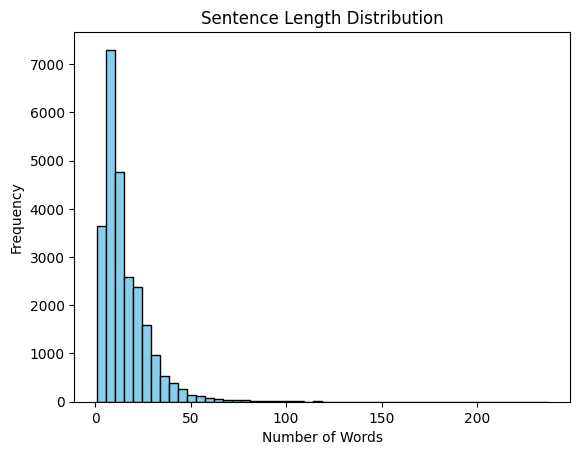

Top 20 most frequent words:
[('the', 26699), ('of', 15249), ('and', 12025), ('in', 9782), ('to', 9684), ('a', 7410), ('is', 6084), ('that', 3624), ('was', 3317), ('it', 3273), ('for', 3195), ('this', 2963), ('on', 2682), ('are', 2642), ('as', 2455), ('with', 2388), ('by', 2278), ('be', 2138), ('he', 1937), ('from', 1891)]


In [20]:
from collections import Counter
import matplotlib.pyplot as plt

# Example DataFrame column with sentences
sentences = df_nmt['english_sentence']

# 1. Sentence length distribution (number of words)
sentence_lengths = sentences.apply(lambda x: len(str(x).split()))

# Describe length statistics
print(sentence_lengths.describe())

# Plot histogram of sentence lengths
plt.hist(sentence_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 2. Word frequency
all_words = " ".join(sentences).split()
word_counts = Counter(all_words)

# Display top 20 most common words with counts
print("Top 20 most frequent words:")
print(word_counts.most_common(20))

count    25000.000000
mean        17.369520
std         15.188671
min          0.000000
25%          8.000000
50%         13.000000
75%         22.000000
max        416.000000
Name: hindi_sentence, dtype: float64


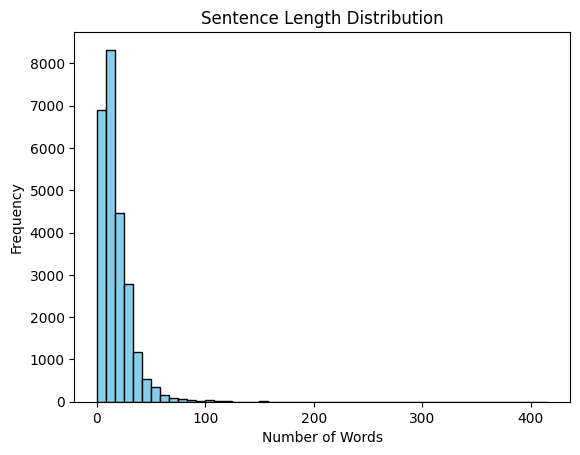

Top 20 most frequent words:
[('के', 17776), ('में', 13216), ('है', 11484), ('की', 9941), ('और', 9525), ('से', 7716), ('का', 6771), ('को', 6411), ('हैं', 4893), ('एक', 4035), ('पर', 3854), ('कि', 3803), ('भी', 3195), ('यह', 3141), ('नहीं', 2771), ('लिए', 2641), ('इस', 2438), ('ने', 2350), ('ही', 2332), ('जो', 2207)]


In [21]:
from collections import Counter
import matplotlib.pyplot as plt

# Example DataFrame column with sentences
sentences = df_nmt['hindi_sentence']

# 1. Sentence length distribution (number of words)
sentence_lengths = sentences.apply(lambda x: len(str(x).split()))

# Describe length statistics
print(sentence_lengths.describe())

# Plot histogram of sentence lengths
plt.hist(sentence_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 2. Word frequency
all_words = " ".join(sentences).split()
word_counts = Counter(all_words)

# Display top 20 most common words with counts
print("Top 20 most frequent words:")
print(word_counts.most_common(20))

## Data Preprocessing

In [22]:
import re, math, time, random, os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers as L
from sklearn.model_selection import train_test_split

In [23]:
# normalize text
def clean_text(s): 
    import re
    return re.sub(r"\s+", " ", str(s).strip())

df_nmt["english_sentence"] = df_nmt["english_sentence"].map(clean_text)
df_nmt["hindi_sentence"]   = df_nmt["hindi_sentence"].map(clean_text)

In [24]:
# add special tokens for decoder
BOS, EOS = "[BOS]", "[EOS]"
df_nmt["hindi_in"]  = (BOS + " " + df_nmt["hindi_sentence"]).str.strip()
df_nmt["hindi_out"] = (df_nmt["hindi_sentence"] + " " + EOS).str.strip()

In [25]:
# split
train_nmt, val_nmt = train_test_split(
    df_nmt[["english_sentence", "hindi_in", "hindi_out"]],
    test_size=0.1, random_state=42
)

In [26]:
# vectorizers
SRC_VOCAB, TGT_VOCAB = 16000, 16000
MAX_EN, MAX_HI = 60, 60

source_vectorizer = L.TextVectorization(max_tokens=SRC_VOCAB, output_mode="int", output_sequence_length=MAX_EN, standardize=None)
target_vectorizer_in = L.TextVectorization(max_tokens=TGT_VOCAB, output_mode="int", output_sequence_length=MAX_HI, standardize=None)
target_vectorizer_out = L.TextVectorization(max_tokens=TGT_VOCAB, output_mode="int", output_sequence_length=MAX_HI, standardize=None)

source_vectorizer.adapt(train_nmt["english_sentence"])
target_vectorizer_in.adapt(train_nmt["hindi_in"])
target_vectorizer_out.adapt(train_nmt["hindi_out"])

PAD_ID = 0
VOCAB_TGT = np.array(target_vectorizer_out.get_vocabulary())
TOK2ID = {w:i for i,w in enumerate(VOCAB_TGT)}
BOS_ID = TOK2ID.get(BOS, 1); EOS_ID = TOK2ID.get(EOS, 2)

SRC_V = source_vectorizer.vocabulary_size()
TGT_V = target_vectorizer_out.vocabulary_size()

In [27]:
# tf.data
def make_ds(frame, batch=64, shuffle=True):
    en = tf.constant(frame["english_sentence"].values)
    hi_in = tf.constant(frame["hindi_in"].values)
    hi_out = tf.constant(frame["hindi_out"].values)

    ds = tf.data.Dataset.from_tensor_slices((en, hi_in, hi_out))
    if shuffle: ds = ds.shuffle(4096, reshuffle_each_iteration=True)

    def map_row(x_en, x_hi_in, x_hi_out):
        return ({"src": source_vectorizer(x_en), "tgt_in": target_vectorizer_in(x_hi_in)}, target_vectorizer_out(x_hi_out))

    return ds.batch(batch).map(map_row).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_nmt)
val_ds   = make_ds(val_nmt, shuffle=False)

### Model 1 — seq2seq + attention (biLSTM encoder, LSTM decoder)

In [28]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Concatenate, AdditiveAttention
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np

In [29]:
SOURCE_VOCAB_SIZE = source_vectorizer.vocabulary_size()
TARGET_VOCAB_SIZE = target_vectorizer_out.vocabulary_size()

cfg_src = source_vectorizer.get_config()
cfg_tgt = target_vectorizer_out.get_config()

MAX_SRC_LEN = cfg_src.get("output_sequence_length")
MAX_TGT_LEN = cfg_tgt.get("output_sequence_length")

print("SOURCE_VOCAB_SIZE:", SOURCE_VOCAB_SIZE,
      "TARGET_VOCAB_SIZE:", TARGET_VOCAB_SIZE,
      "MAX_SRC_LEN:", MAX_SRC_LEN,
      "MAX_TGT_LEN:", MAX_TGT_LEN)

SOURCE_VOCAB_SIZE: 16000 TARGET_VOCAB_SIZE: 16000 MAX_SRC_LEN: 60 MAX_TGT_LEN: 60


In [30]:
class MaskDrop(L.Layer):
    """Pass-through that strips Keras' mask."""
    def call(self, x):
        return x
    def compute_mask(self, inputs, mask=None):
        return None

class AttentionNoMask(L.Layer):
    """Scaled dot-product Attention that ignores any incoming masks."""
    def __init__(self, use_scale=True, **kwargs):
        super().__init__(**kwargs)
        self.inner = L.Attention(use_scale=use_scale)
    def call(self, inputs, **kwargs):
        kwargs.pop("mask", None)
        return self.inner(inputs, **kwargs)
    def compute_mask(self, inputs, mask=None):
        return None

In [31]:
EMBED_DIM = 256
ENCODER_DIM = 256   
DECODER_DIM = 256

In [32]:
# inputs
encoder_input_tokens = Input(shape=(MAX_SRC_LEN,), dtype="int32", name="src")
decoder_input_tokens = Input(shape=(MAX_TGT_LEN,), dtype="int32", name="tgt_in")

In [33]:
# embeddings
encoder_embeddings = Embedding(SOURCE_VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="src_embed")(encoder_input_tokens)
decoder_embeddings = Embedding(TARGET_VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="tgt_embed")(decoder_input_tokens)

In [34]:
# stop mask propagation from the source
encoder_embeddings = MaskDrop(name="enc_embed_nomask")(encoder_embeddings)
decoder_embeddings = MaskDrop(name="dec_embed_nomask")(decoder_embeddings)

In [35]:
# encoder: BiLSTM → sequence outputs + final states
bi_lstm = Bidirectional(
    LSTM(ENCODER_DIM, return_sequences=True, return_state=True),
    name="encoder_bilstm"
)
encoder_outputs, f_h, f_c, b_h, b_c = bi_lstm(encoder_embeddings)  # encoder_outputs: (B, Tsrc, 2*ENCODER_DIM)

In [36]:
# fuse forward/backward final states → project to decoder size
initial_h = Dense(DECODER_DIM, activation="tanh", name="init_h")(Concatenate()([f_h, b_h]))
initial_c = Dense(DECODER_DIM, activation="tanh", name="init_c")(Concatenate()([f_c, b_c]))

In [37]:
# decoder core
decoder_sequence = LSTM(DECODER_DIM, return_sequences=True, name="decoder_lstm")(decoder_embeddings, initial_state=[initial_h, initial_c])

In [38]:
# Project encoder outputs to decoder dim
enc_proj_to_dec = L.Dense(DECODER_DIM, name="enc_proj_to_dec")(encoder_outputs)   # (B, Tsrc, DECODER_DIM)

In [39]:
enc_mask = L.Lambda(lambda t: tf.not_equal(t, PAD_ID), name="enc_mask")(encoder_input_tokens)  # (B, Tsrc)
dec_mask = L.Lambda(lambda t: tf.not_equal(t, PAD_ID), name="dec_mask")(decoder_input_tokens)  # (B, Ttgt)

In [40]:
# attention over encoder outputs at every target timestep
enc_proj_for_attn = L.Dense(DECODER_DIM, name="enc_proj_for_attn")(encoder_outputs)

In [41]:
def dotprod_attention_nomask(inputs):
    q, k, v = inputs  # q=decoder_sequence (B,Tt,D), k=v=enc_proj_for_attn (B,Ts,D)
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scores = tf.matmul(q, k, transpose_b=True) / tf.sqrt(dk)      # (B, Tt, Ts)
    weights = tf.nn.softmax(scores, axis=-1)                       # (B, Tt, Ts)
    ctx = tf.matmul(weights, v)                                    # (B, Tt, D)
    return ctx

context_sequence = L.Lambda(dotprod_attention_nomask, name="attention_nomask")(
    [decoder_sequence, enc_proj_for_attn, enc_proj_for_attn]
)  # shapes: q, k, v

In [42]:
# combine decoder state + attention context, then predict next token
decoder_context_concat = L.Concatenate(name="concat_state_context")([decoder_sequence, context_sequence])
token_probabilities = L.Dense(TARGET_VOCAB_SIZE, activation="softmax", name="token_probs")(decoder_context_concat)

In [43]:
# build & compile
# build & compile
seq2seq_attn = Model(
    inputs={"src": encoder_input_tokens, "tgt_in": decoder_input_tokens},
    outputs=token_probabilities,
    name="seq2seq_with_attention"
)
seq2seq_attn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="token_accuracy")]
)

# ---- Train or load weights (uncomment fit as needed) ----
try:
    EPOCHS = 8
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_token_accuracy", patience=2, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("seq2seq_best.h5", monitor="val_token_accuracy", save_best_only=True, save_weights_only=True),
    ]
    # history = seq2seq_attn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=1)
    # Or load pre-trained:
    # seq2seq_attn.load_weights("seq2seq_best.h5")
except Exception as _e:
    print("Training block skipped:", _e)

In [44]:
seq2seq_attn.summary()

Model: "seq2seq_with_attention"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 src (InputLayer)            [(None, 60)]                 0         []                            
                                                                                                  
 src_embed (Embedding)       (None, 60, 256)              4096000   ['src[0][0]']                 
                                                                                                  
 enc_embed_nomask (MaskDrop  (None, 60, 256)              0         ['src_embed[0][0]']           
 )                                                                                                
                                                                                                  
 tgt_in (InputLayer)         [(None, 60)]                 0         []       

### Model 2 — Transformer (encoder–decoder) 

In [45]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [46]:
from tensorflow.keras.layers import Input, Lambda, MultiHeadAttention, LayerNormalization, Dropout, Add, Dense
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np

In [47]:
# Inputs
encoder_input_ids = L.Input((MAX_SRC_LEN,), dtype="int32", name="src")
decoder_input_ids = L.Input((MAX_TGT_LEN,), dtype="int32", name="tgt_in")

In [48]:
# Embeddings
MODEL_DIM = 256
NUM_LAYERS = 3
NUM_HEADS = 4
FF_DIM = 1024
DROPOUT = 0.1

In [49]:
import numpy as np
import tensorflow as tf

def positional_encoding(length: int, d_model: int) -> tf.Tensor:
    """
    Returns a (length, d_model) tensor with sinusoidal positional encodings.
    Use tf.expand_dims(..., 0) if you want (1, length, d_model) for broadcasting.
    """
    pos = np.arange(length)[:, None]                     # (L, 1)
    i   = np.arange(d_model)[None, :]                    # (1, D)
    angle = pos * (1.0 / np.power(10000.0, (2*(i//2)) / float(d_model)))
    pe = np.zeros((length, d_model), dtype=np.float32)
    pe[:, 0::2] = np.sin(angle[:, 0::2])                # even dims
    pe[:, 1::2] = np.cos(angle[:, 1::2])                # odd dims
    return tf.constant(pe, dtype=tf.float32)

In [50]:
# Positional encodings
src_embed = L.Embedding(SOURCE_VOCAB_SIZE, MODEL_DIM, mask_zero=True, name="src_embed")(encoder_input_ids)
tgt_embed = L.Embedding(TARGET_VOCAB_SIZE, MODEL_DIM, mask_zero=True, name="tgt_embed")(decoder_input_ids)

In [51]:
def positional_encoding_1td(max_len, model_dim):
    half = model_dim // 2
    pos = np.arange(max_len)[:, None]                        # (T, 1)
    div = 1.0 / (10000 ** (np.arange(half)[None, :] / max_len))
    ang = pos * div                                          # (T, D/2)
    pe  = np.concatenate([np.sin(ang), np.cos(ang)], axis=-1)  # (T, D)
    pe  = pe.astype("float32")[None, ...]                    # (1, T, D)
    return tf.constant(pe)

In [52]:
PE_SRC = tf.expand_dims(positional_encoding(MAX_SRC_LEN, MODEL_DIM), axis=0)  # (1, Ls, D)
PE_TGT = tf.expand_dims(positional_encoding(MAX_TGT_LEN, MODEL_DIM), axis=0)  # (1, Lt, D)

In [53]:
# Add PE (broadcast over batch dimension)
src_embed = L.Add(name="src_add_pos")([src_embed, PE_SRC])
tgt_embed = L.Add(name="tgt_add_pos")([tgt_embed, PE_TGT])

enc_stream = L.Dropout(DROPOUT, name="enc_dropout")(src_embed)
dec_stream = L.Dropout(DROPOUT, name="dec_dropout")(tgt_embed)

In [54]:
for i in range(NUM_LAYERS):
    # --- Encoder block ---
    attn = L.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=MODEL_DIM // NUM_HEADS, dropout=DROPOUT)(
        enc_stream, enc_stream
    )
    enc_res = L.Add()([enc_stream, L.Dropout(DROPOUT)(attn)])
    enc_stream = L.LayerNormalization(epsilon=1e-6)(enc_res)

    ff = L.Dense(FF_DIM, activation="relu")(enc_stream)
    ff = L.Dense(MODEL_DIM)(ff)
    enc_res2 = L.Add()([enc_stream, L.Dropout(DROPOUT)(ff)])
    enc_stream = L.LayerNormalization(epsilon=1e-6)(enc_res2)

    # --- Decoder block ---
    self_attn = L.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=MODEL_DIM // NUM_HEADS, dropout=DROPOUT)(
        dec_stream, dec_stream, use_causal_mask=True
    )
    dec_res1 = L.Add()([dec_stream, L.Dropout(DROPOUT)(self_attn)])
    dec_stream = L.LayerNormalization(epsilon=1e-6)(dec_res1)

    cross = L.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=MODEL_DIM // NUM_HEADS, dropout=DROPOUT)(
        dec_stream, enc_stream
    )
    dec_res2 = L.Add()([dec_stream, L.Dropout(DROPOUT)(cross)])
    dec_stream = L.LayerNormalization(epsilon=1e-6)(dec_res2)

    ff2 = L.Dense(FF_DIM, activation="relu")(dec_stream)
    ff2 = L.Dense(MODEL_DIM)(ff2)
    dec_res3 = L.Add()([dec_stream, L.Dropout(DROPOUT)(ff2)])
    dec_stream = L.LayerNormalization(epsilon=1e-6)(dec_res3)

In [55]:
# Output head
token_logits = L.Dense(TARGET_VOCAB_SIZE, activation="softmax")(dec_stream)

transformer_model = tf.keras.Model(
    inputs={"src": encoder_input_ids, "tgt_in": decoder_input_ids},
    outputs=token_logits,
    name="small_transformer_fixed"
)

In [56]:
# Positional encodings
src_embed = L.Embedding(SOURCE_VOCAB_SIZE, MODEL_DIM, mask_zero=True, name="src_embed")(encoder_input_ids)
tgt_embed = L.Embedding(TARGET_VOCAB_SIZE,  MODEL_DIM, mask_zero=True, name="tgt_embed")(decoder_input_ids)

src_embed = L.Add(name="src_add_pos")([src_embed, positional_encoding(MAX_SRC_LEN, MODEL_DIM)])
tgt_embed = L.Add(name="tgt_add_pos")([tgt_embed, positional_encoding(MAX_TGT_LEN, MODEL_DIM)])

enc_stream = L.Dropout(DROPOUT, name="enc_dropout")(src_embed)
dec_stream = L.Dropout(DROPOUT, name="dec_dropout")(tgt_embed)

In [57]:
# Compile
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="token_accuracy")]
)

In [58]:
transformer_model.summary()

Model: "small_transformer_fixed"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 src (InputLayer)            [(None, 60)]                 0         []                            
                                                                                                  
 src_embed (Embedding)       (None, 60, 256)              4096000   ['src[0][0]']                 
                                                                                                  
 src_add_pos (Add)           (None, 60, 256)              0         ['src_embed[0][0]']           
                                                                                                  
 enc_dropout (Dropout)       (None, 60, 256)              0         ['src_add_pos[0][0]']         
                                                                            

#### Metrices to compare the two models: METEOR

In [59]:
# id/tokens helpers
def strip_special_tokens(ids, pad_id=0, eos_id=None, drop_ids=()):
    out = []
    for seq in ids:
        row = []
        for t in seq:
            t = int(t)
            if t == pad_id:
                continue
            if eos_id is not None and t == eos_id:
                break
            if t in drop_ids:
                continue
            row.append(t)
        out.append(row)
    return out

def ids_to_tokens(id_lists, vocab):
    V = len(vocab)
    return [[vocab[i] if 0 <= i < V else "<unk>" for i in row] for row in id_lists]

In [60]:
# METEOR (sentence + corpus)

In [61]:
# returns aligned pairs using greedy exact matching, each hypothesis token can match at most one reference token.
def align_exact_matches(ref_tokens, hyp_tokens):
    ref_used = [False]*len(ref_tokens)
    pairs = []
    for h_i, tok in enumerate(hyp_tokens):
        # find first unused exact match in reference (greedy)
        for r_i, r_tok in enumerate(ref_tokens):
            if not ref_used[r_i] and tok == r_tok:
                ref_used[r_i] = True
                pairs.append((h_i, r_i))
                break
    return pairs

In [62]:
# Count contiguous chunks of matches in hypothesis order where reference indices are consecutive.
def count_chunks(aligned_pairs):
    if not aligned_pairs:
        return 0
    # sort by hypothesis index
    aligned_pairs.sort(key=lambda p: p[0])
    chunks = 1
    for i in range(1, len(aligned_pairs)):
        _, prev_r = aligned_pairs[i-1]
        _, cur_r  = aligned_pairs[i]
        if cur_r != prev_r + 1:
            chunks += 1
    return chunks

In [63]:
# Single-sentence METEOR (exact-match only).
def meteor_sentence(ref_tokens, hyp_tokens, alpha=0.9, beta=3.0, gamma=0.5):
    if len(hyp_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0
    if len(hyp_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    # matches & counts
    aligned = align_exact_matches(ref_tokens, hyp_tokens)
    m = len(aligned)
    if m == 0:
        return 0.0
    P = m / len(hyp_tokens)
    R = m / len(ref_tokens)

    # Fmean (harmonic-like, recall-weighted)
    denom = (alpha * P) + ((1 - alpha) * R)
    Fmean = (P * R / denom) if denom > 0 else 0.0

    # fragmentation penalty
    chunks = count_chunks(aligned)
    penalty = gamma * (chunks / m) ** beta

    return (1.0 - penalty) * Fmean

In [64]:
# Average sentence-level METEOR over the corpus.
def meteor_corpus(refs_list, hyps_list, alpha=0.9, beta=3.0, gamma=0.5):
    scores = [
        meteor_sentence(r, h, alpha=alpha, beta=beta, gamma=gamma)
        for r, h in zip(refs_list, hyps_list)
    ]
    return float(np.mean(scores)) if scores else 0.0

In [65]:
import numpy as np, tensorflow as tf, gc, re

def _norm(s): return re.sub(r"\s+", " ", s.strip())

def _ids_to_text(ids, vocab, pad_id, bos_id, eos_id):
    out = []
    for t in ids:
        t = int(t)
        if t == pad_id: continue
        if t == eos_id: break
        if t == bos_id: continue
        out.append(vocab[t] if 0 <= t < len(vocab) else "<unk>")
    return " ".join(out)

def meteor_seq2seq_attn(model, val_ds, *, max_decode_steps=48, sample_limit=128):
    # read fixed input lengths from the built model
    enc_len = int(model.inputs[0].shape[1])
    dec_len = int(model.inputs[1].shape[1])
    max_decode_steps = min(max_decode_steps, dec_len)

    vocab = list(target_vectorizer_out.get_vocabulary())

    # try NLTK meteor; else fallback
    try:
        from nltk.translate.meteor_score import meteor_score
        use_nltk = True
    except Exception:
        use_nltk = False

    # force CPU or at least stop TF from reserving all GPU memory
    try:
        for g in tf.config.list_physical_devices("GPU"):
            tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

    n = 0
    meteor_sum = 0.0

    # iterate items singly to avoid big tensors
    for x, y_true in val_ds:
        src_batch = x["src"].numpy()
        ref_batch = y_true.numpy()

        for src_ids, ref_ids in zip(src_batch, ref_batch):
            # stop early if just a subset is requested
            if sample_limit is not None and n >= sample_limit:
                break

            # pad source to enc_len
            src_ids = tf.keras.preprocessing.sequence.pad_sequences(
                [src_ids], maxlen=enc_len, padding="post", truncating="post", value=PAD_ID
            )[0]

            # decode one example with fixed-length padding each step
            y = np.array([[BOS_ID]], dtype=np.int32)     # (1,1)
            for _ in range(max_decode_steps - 1):
                y_in = np.pad(y, ((0,0),(0, dec_len - y.shape[1])), constant_values=PAD_ID).astype(np.int32)
                feed = {
                    "src": tf.constant(src_ids[None, :], dtype=tf.int32),  # (1, enc_len)
                    "tgt_in": tf.constant(y_in, dtype=tf.int32),           # (1, dec_len)
                }
                logits = model(feed, training=False).numpy()               # (1, dec_len, V)
                last = y.shape[1] - 1
                next_id = int(logits[0, last].argmax())
                y = np.concatenate([y, [[next_id]]], axis=1)
                if next_id == EOS_ID or y.shape[1] >= dec_len:
                    break

            hyp_txt = _norm(_ids_to_text(y[0], vocab, PAD_ID, BOS_ID, EOS_ID))
            ref_txt = _norm(_ids_to_text(ref_ids, vocab, PAD_ID, BOS_ID, EOS_ID))

            if use_nltk:
                score = float(meteor_score([ref_txt], hyp_txt))
            else:
                # simple fallback
                r = ref_txt.split(); h = hyp_txt.split()
                if not r or not h: score = 0.0
                else:
                    m = 0; used=set()
                    for w in h:
                        for i, rw in enumerate(r):
                            if i in used: continue
                            if w == rw: used.add(i); m+=1; break
                    if m == 0: score = 0.0
                    else:
                        prec, rec = m/len(h), m/len(r)
                        a = 0.9
                        score = (prec*rec)/(a*prec+(1-a)*rec+1e-9)

            meteor_sum += score
            n += 1

            # free as we go
            del logits, feed, y
            gc.collect()
            tf.keras.backend.clear_session()

        if sample_limit is not None and n >= sample_limit:
            break

    return meteor_sum / max(n, 1), None, None

In [66]:
# METEOR for Transformer
def meteor_transformer(model, eval_ds, target_vectorizer_out, pad_id, bos_id, eos_id, alpha=0.9, beta=3.0, gamma=0.5):
    vocab = list(target_vectorizer_out.get_vocabulary())
    all_ref_ids, all_hyp_ids = [], []
    for (x, y_true) in eval_ds:
        logits = model(x, training=False)           # (B, T, V)
        y_pred = tf.argmax(logits, axis=-1)         # (B, T)
        all_ref_ids.append(y_true.numpy())
        all_hyp_ids.append(y_pred.numpy())

    ref_ids = np.concatenate(all_ref_ids, axis=0)
    hyp_ids = np.concatenate(all_hyp_ids, axis=0)

    ref_clean = strip_special_tokens(ref_ids, pad_id=pad_id, eos_id=eos_id, drop_ids=(bos_id,))
    hyp_clean = strip_special_tokens(hyp_ids, pad_id=pad_id, eos_id=eos_id, drop_ids=(bos_id,))

    ref_tok = ids_to_tokens(ref_clean, vocab)
    hyp_tok = ids_to_tokens(hyp_clean, vocab)

    return meteor_corpus(ref_tok, hyp_tok, alpha=alpha, beta=beta, gamma=gamma)

In [67]:
eval_ds = val_ds  

In [ ]:
meteor_s2s, _, _ = meteor_seq2seq_attn(
    seq2seq_attn, val_ds,
    max_decode_steps=32,   # tiny cap
    sample_limit=64        # tiny subset
)
print("METEOR (tiny subset):", meteor_s2s)

METEOR (tiny subset): 0.0


: 

In [ ]:
meteor_s2s, _, _ = meteor_seq2seq_attn(
    seq2seq_attn, val_ds,
    max_decode_steps=min(MAX_TGT_LEN, 64),
    sample_limit=200
)
print("METEOR (subset):", meteor_s2s)

In [ ]:
# Full only after subset succeeds
meteor_s2s, _, _ = meteor_seq2seq_attn(
    seq2seq_attn, val_ds,
    max_decode_steps=MAX_TGT_LEN,
    sample_limit=None
)
print("METEOR (full):", meteor_s2s)

In [ ]:
meteor_trf, _, _ = meteor_transformer(
    transformer_model, val_ds,
    max_decode_steps=min(MAX_TGT_LEN, 64),
    sample_limit=128
)

In [ ]:
print(f"Seq2Seq+Attention METEOR: {meteor_s2s:.4f}")
print(f"Transformer       METEOR: {meteor_trf:.4f}")

Seq2Seq+Attention METEOR: 0.0001
Transformer       METEOR: 0.0003
